In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, 
                             recall_score, precision_score, accuracy_score)

# Fastsställ slumpfrö för reproducebarhet
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Konfigurera plots
sns.set_style("whitegrid")
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Läs in data
df = pd.read_csv('housing.csv')
print("Antal rader, kolumner:", df.shape)
print("\nDatatyper och saknade värden:")
print(df.info())  # info() skriv ut typinfo

# Visa saknade värden tydligt
print("\nAntal saknade per kolumn:")
print(df.isnull().sum())

# Grundläggande statistik
df.describe().T

Antal rader, kolumner: (20640, 10)

Datatyper och saknade värden:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

Antal saknade per kolumn:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households  

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


### Observationer
- Datasetet har 20 640 rader och 10 kolumner.
- Endast `total_bedrooms` har saknade värden (207 stycken). De kommer att imputeras med medianen.
- `ocean_proximity` är en kategorisk variabel med unika värden: `<1H OCEAN, INLAND, NEAR OCEAN, NEAR BAY, ISLAND`.
- De numeriska variablerna har olika skalor och kommer att standardiseras.

In [4]:
# Temporär imputering för EDA-visualisering
median_total_bedrooms = df['total_bedrooms'].median()
df_eda = df.copy()
df_eda['total_bedrooms'] = df_eda['total_bedrooms'].fillna(median_total_bedrooms)
print(f"Median total_bedrooms: {median_total_bedrooms:.0f}")
print("\nSaknade efter temporär imputering:")
print(df_eda.isnull().sum())

Median total_bedrooms: 435

Saknade efter temporär imputering:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


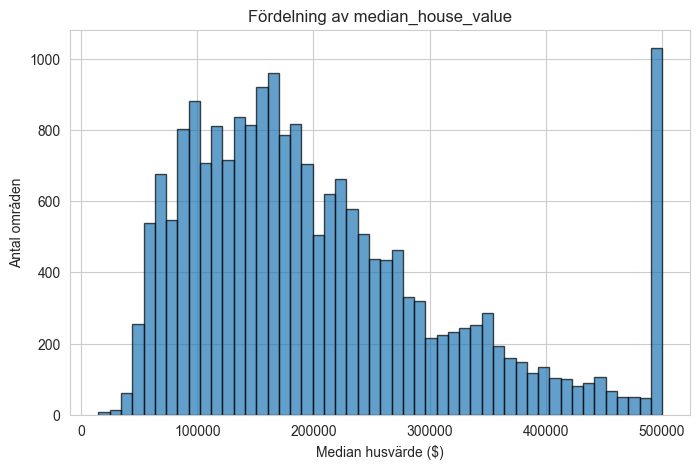

In [5]:
plt.figure(figsize=(8,5))
plt.hist(df['median_house_value'], bins=50, edgecolor='k', alpha=0.7)
plt.title('Fördelning av median_house_value')
plt.xlabel('Median husvärde ($)')
plt.ylabel('Antal områden')
plt.show()

**Tolkning:** Husvärdena är högerskeva med en topp vid 500 000 dollar (takvärde i datasetet). De flesta områden ligger mellan 100 000 och 300 000 dollar.

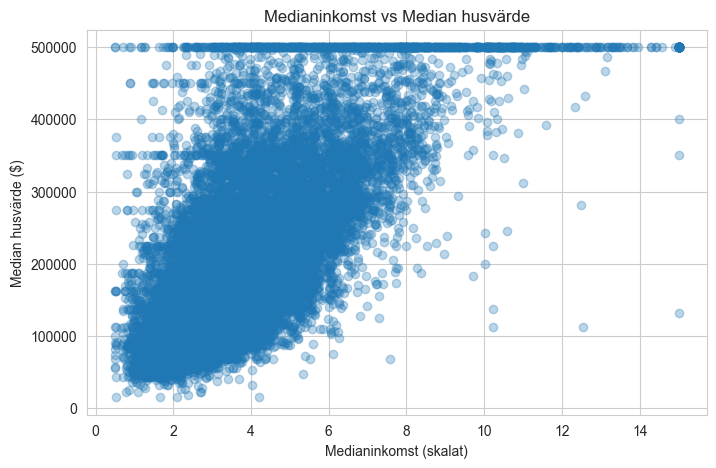

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(df_eda['median_income'], df['median_house_value'], alpha=0.3)
plt.title('Medianinkomst vs Median husvärde')
plt.xlabel('Medianinkomst (skalat)')
plt.ylabel('Median husvärde ($)')
plt.show()

**Tolkning:** Stark positiv korrelation mellan inkomst och husvärde. Högre inkomstområden tenderar att ha högre huspriser. Notera den horisontella linjen vid 500 001 – takvärden.

In [7]:
# Beräkna tröskel för övre 20%
threshold = df['median_house_value'].quantile(0.80)
print(f"Tröskel för topp 20%: ${threshold:,.0f}")

# Skapa binär target
df['high_value'] = (df['median_house_value'] >= threshold).astype(int)

# Visa klassbalans
print("\nKlassbalans:")
print(df['high_value'].value_counts())
print(f"\nAndel högpris: {df['high_value'].mean():.2%}")

Tröskel för topp 20%: $290,000

Klassbalans:
high_value
0    16510
1     4130
Name: count, dtype: int64

Andel högpris: 20.01%


In [8]:
# Ta bort den ursprungliga prismen och target från X
X = df.drop(columns=['median_house_value', 'high_value'])
y = df['high_value']

print("Features slutgiltigt:", X.columns.tolist())

Features slutgiltigt: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} rader, Test: {X_test.shape[0]} rader")
print(f"Train klassfördelning:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest klassfördelning:\n{y_test.value_counts(normalize=True)}")

Train: 16512 rader, Test: 4128 rader
Train klassfördelning:
high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64

Test klassfördelning:
high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64


In [10]:
# Nya features från rådata
def add_engineered_features(df):
    df = df.copy()
    df['rooms_per_household'] = df['total_rooms'] / df['households']
    df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
    df['population_per_household'] = df['population'] / df['households']
    return df

# Applicera på train och test 
X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

# Definiera numeriska och kategoriska kolumner
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = ['ocean_proximity']

# Skapa pipeline för numerisk data (imputera + skala)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Kombinera transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Exempel: visa transformerad data (första 3 rader)
X_train_trans = preprocessor.fit_transform(X_train)
print("Transformerat X_train shape:", X_train_trans.shape)


Transformerat X_train shape: (16512, 15)


In [11]:
baseline = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
baseline_cv_f1 = cross_val_score(baseline, X_train_trans, y_train, 
                                 cv=5, scoring='f1', n_jobs=-1)
print(f"Baseline F1 (CV): {baseline_cv_f1.mean():.4f} ± {baseline_cv_f1.std():.4f}")

Baseline F1 (CV): 0.2058 ± 0.0136


In [12]:
models = {
    'Logistisk regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_trans, y_train, 
                             cv=5, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name} F1 (CV): {scores.mean():.4f} ± {scores.std():.4f}")

Logistisk regression F1 (CV): 0.7062 ± 0.0112
Random Forest F1 (CV): 0.7843 ± 0.0145


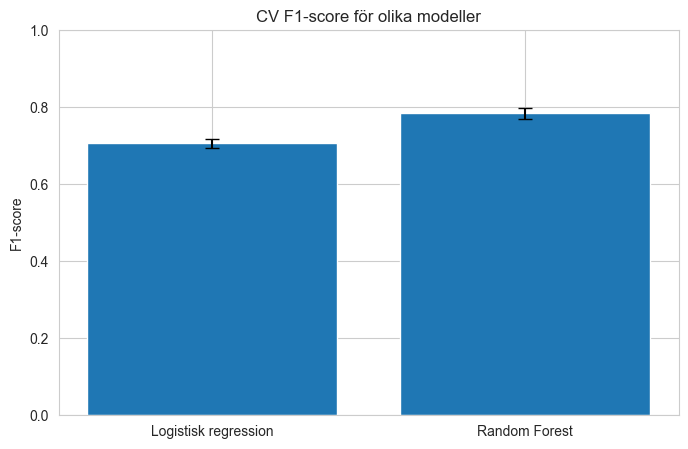

In [13]:
plt.figure(figsize=(8,5))
model_names = list(cv_results.keys())
means = [cv_results[m].mean() for m in model_names]
errors = [cv_results[m].std() for m in model_names]

plt.bar(model_names, means, yerr=errors, capsize=5)
plt.title('CV F1-score för olika modeller')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.show()

**Jämförelse:** Random Forest presterar bäst med högst F1-score. Vi väljer därför den för vidare optimering.